# QPEI Round 5 — Final Scoring + Sensitivity + Anonymization

This notebook:
1. Loads the master Excel
2. Applies the item → domain crosswalk
3. Computes school-level domain scores and weighted QPEI
4. **Anonymizes schools** (keeps only Upazila + Urban/Rural)
5. Runs sensitivity and leave-one-domain-out analyses
6. Saves clean tables and figures

**Before running:** Edit the CROSSWALK list so item codes match your actual column names.

In [3]:
# ============================================================
# 0. SETUP
# ============================================================
!pip -q install openpyxl

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json, warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("/content/drive/MyDrive/QPEI/QPE_MASTER_Cleaned_IDs_Translated_Analysis.xlsx")
OUTPUT_DIR = Path("/content/drive/MyDrive/QPEI/qpei_round5_scoring")
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
LOG_DIR = OUTPUT_DIR / "logs"

for p in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("=" * 90)
print("QPEI ROUND 5 — SCORING + SENSITIVITY + ANONYMIZATION")
print("=" * 90)
print("Data   :", DATA_PATH, "| exists:", DATA_PATH.exists())
print("Output :", OUTPUT_DIR)
print("Started:", datetime.now().isoformat(timespec="seconds"))

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Master workbook not found: {DATA_PATH}")

Mounted at /content/drive
QPEI ROUND 5 — SCORING + SENSITIVITY + ANONYMIZATION
Data   : /content/drive/MyDrive/QPEI/QPE_MASTER_Cleaned_IDs_Translated_Analysis.xlsx | exists: True
Output : /content/drive/MyDrive/QPEI/qpei_round5_scoring
Started: 2026-09-05T13:03:18


In [4]:
# ============================================================
# 1. LOAD SHEETS
# ============================================================
xl = pd.ExcelFile(DATA_PATH)
print("Sheets:", xl.sheet_names)

teacher = pd.read_excel(DATA_PATH, sheet_name="Teacher_Survey")
parent  = pd.read_excel(DATA_PATH, sheet_name="Parent_Survey")
student = pd.read_excel(DATA_PATH, sheet_name="Student_Questionnaire")
obs     = pd.read_excel(DATA_PATH, sheet_name="Classroom_Observation")
env     = pd.read_excel(DATA_PATH, sheet_name="School_Environment")

# Harmonise school_id column name
for df in [teacher, parent, student, obs, env]:
    if "school_id" not in df.columns:
        for c in df.columns:
            if "school" in c.lower() and "id" in c.lower():
                df.rename(columns={c: "school_id"}, inplace=True)
                break

print(f"Teacher : {teacher.shape} | unique schools: {teacher['school_id'].nunique()}")
print(f"Parent  : {parent.shape}  | unique schools: {parent['school_id'].nunique()}")
print(f"Student : {student.shape} | unique schools: {student['school_id'].nunique()}")
print(f"Obs     : {obs.shape}     | unique schools: {obs['school_id'].nunique()}")
print(f"Env     : {env.shape}     | unique schools: {env['school_id'].nunique()}")

Sheets: ['Summary', 'Teacher_Survey', 'Parent_Survey', 'Student_Questionnaire', 'Classroom_Observation', 'School_Environment', 'Codebook', 'Id_Enumerator_School', 'School_Master', 'Translation_Glossary', 'ID_Translation_Report']
Teacher : (163, 51) | unique schools: 32
Parent  : (316, 41)  | unique schools: 32
Student : (378, 35) | unique schools: 32
Obs     : (8, 56)     | unique schools: 8
Env     : (32, 41)     | unique schools: 32


In [5]:
# ============================================================
# 2. ITEM → DOMAIN CROSSWALK
#    IMPORTANT: Replace the item codes (tq1, sq1, etc.) with the
#    real column names from your master file before final run.
# ============================================================

CROSSWALK = [
    # D1 Teacher competence & pedagogy (20%)
    ("tq1",  "Teacher", "D1", 1),
    ("tq2",  "Teacher", "D1", 1),
    ("tq3",  "Teacher", "D1", 1),
    ("tq4",  "Teacher", "D1", 1),
    ("tq5",  "Teacher", "D1", 1),
    ("tq6",  "Teacher", "D1", 1),
    ("sq1",  "Student", "D1", 1),
    ("sq2",  "Student", "D1", 1),
    ("sq3",  "Student", "D1", 1),
    ("sq4",  "Student", "D1", 1),

    # D2 Curriculum & assessment (15%)
    ("tq7",  "Teacher", "D2", 1),
    ("tq8",  "Teacher", "D2", 1),
    ("tq9",  "Teacher", "D2", 1),
    ("tq10", "Teacher", "D2", 1),
    ("tq11", "Teacher", "D2", 1),
    ("co1",  "Observation", "D2", 1),
    ("co2",  "Observation", "D2", 1),
    ("co3",  "Observation", "D2", 1),

    # D3 Environment & infrastructure (15%)
    ("tq12", "Teacher", "D3", 1),
    ("tq13", "Teacher", "D3", 1),
    ("pq1",  "Parent",  "D3", 1),
    ("pq2",  "Parent",  "D3", 1),
    ("sq5",  "Student", "D3", 1),
    ("sq6",  "Student", "D3", 1),
    ("se1",  "Environment", "D3", 1),
    ("se2",  "Environment", "D3", 1),

    # D4 Student learning experience & foundational learning conditions (20%)
    ("tq14", "Teacher", "D4", 1),
    ("tq15", "Teacher", "D4", 1),
    ("pq3",  "Parent",  "D4", 1),
    ("pq4",  "Parent",  "D4", 1),
    ("pq5",  "Parent",  "D4", 1),
    ("sq7",  "Student", "D4", 1),
    ("sq8",  "Student", "D4", 1),
    ("sq9",  "Student", "D4", 1),
    ("sq10", "Student", "D4", 1),
    ("sq11", "Student", "D4", 1),
    ("sq12", "Student", "D4", 1),

    # D5 School leadership & community support (15%)
    ("tq16", "Teacher", "D5", 1),
    ("pq6",  "Parent",  "D5", 1),
    ("se3",  "Environment", "D5", 1),

    # D6 Equity & inclusion (15%)
    ("tq17", "Teacher", "D6", 1),
    ("tq18", "Teacher", "D6", 1),
    ("sq13", "Student", "D6", 1),
    ("sq14", "Student", "D6", 1),
    ("co4",  "Observation", "D6", 1),
]

crosswalk_df = pd.DataFrame(CROSSWALK, columns=["item", "source", "domain", "polarity"])
crosswalk_df.to_csv(TABLE_DIR / "R5_Crosswalk_Final.csv", index=False)
print("Crosswalk saved. Domain counts:")
print(crosswalk_df.groupby("domain").size())
print("\nFirst 15 rows of crosswalk:")
display(crosswalk_df.head(15))

Crosswalk saved. Domain counts:
domain
D1    10
D2     8
D3     8
D4    11
D5     3
D6     5
dtype: int64

First 15 rows of crosswalk:


,item,source,domain,polarity
0,tq1,Teacher,D1,1
1,tq2,Teacher,D1,1
2,tq3,Teacher,D1,1
3,tq4,Teacher,D1,1
4,tq5,Teacher,D1,1
5,tq6,Teacher,D1,1
6,sq1,Student,D1,1
7,sq2,Student,D1,1
8,sq3,Student,D1,1
9,sq4,Student,D1,1


In [6]:
# ============================================================
# 3. HELPERS + SCHOOL-LEVEL INDICATOR MEANS
# ============================================================
def clean_likert(series):
    s = pd.to_numeric(series, errors="coerce")
    s = s.where((s >= 1) & (s <= 5))
    return s

def to_0_100(series, polarity=1):
    s = clean_likert(series)
    if polarity == -1:
        s = 6 - s
    return 25 * (s - 1)

SOURCE_MAP = {
    "Teacher": teacher,
    "Parent": parent,
    "Student": student,
    "Observation": obs,
    "Environment": env,
}

school_indicators = {}
all_schools = set()
for df in SOURCE_MAP.values():
    all_schools.update(df["school_id"].dropna().unique())
all_schools = sorted(all_schools)
print(f"Total unique schools across instruments: {len(all_schools)}")

missing_items = []
for _, row in crosswalk_df.iterrows():
    item = row["item"]
    source = row["source"]
    polarity = row["polarity"]
    df = SOURCE_MAP[source]

    if item not in df.columns:
        missing_items.append(f"{item} ({source})")
        continue

    tmp = df[["school_id", item]].copy()
    tmp["score"] = to_0_100(tmp[item], polarity)
    school_mean = tmp.groupby("school_id")["score"].mean()

    for sid, val in school_mean.items():
        if sid not in school_indicators:
            school_indicators[sid] = {}
        school_indicators[sid][item] = val

if missing_items:
    print("\n[WARNING] These items were not found in the data:")
    for m in missing_items:
        print("  -", m)
    print("→ Edit the CROSSWALK list above to match your real column names.")
else:
    print("All crosswalk items found in the data.")

ind_df = pd.DataFrame.from_dict(school_indicators, orient="index")
ind_df.index.name = "school_id"
ind_df = ind_df.reset_index()
print(f"Indicator matrix shape: {ind_df.shape}")
display(ind_df.head())

Total unique schools across instruments: 32
All crosswalk items found in the data.
Indicator matrix shape: (32, 46)


,school_id,tq1,tq2,tq3,tq4,tq5,tq6,sq1,sq2,sq3,sq4,tq7,tq8,tq9,tq10,tq11,tq12,tq13,pq1,pq2,sq5,sq6,se1,se2,tq14,tq15,pq3,pq4,pq5,sq7,sq8,sq9,sq10,sq11,sq12,tq16,pq6,se3,tq17,tq18,sq13,sq14,co1,co2,co3,co4
0,S01,80.000000,65.000000,65.000000,70.000000,75.000000,80.000000,86.363636,61.363636,95.454545,88.636364,85.0,90.000000,85.000000,85.00,55.000000,75.000000,55.000000,92.5,95.000000,84.090909,84.090909,75.0,50.0,85.000000,85.000000,95.000000,90.000000,87.500000,81.818182,93.181818,93.181818,86.363636,88.636364,90.909091,55.000000,50.000000,50.0,70.000000,85.000000,97.727273,97.727273,NaN,NaN,NaN,NaN
1,S02,87.500000,75.000000,56.250000,62.500000,75.000000,93.750000,90.000000,90.000000,90.000000,90.000000,75.0,87.500000,93.750000,93.75,68.750000,68.750000,81.250000,95.0,100.000000,90.000000,90.000000,50.0,75.0,75.000000,68.750000,85.000000,85.000000,90.000000,90.000000,90.000000,90.000000,80.000000,90.000000,90.000000,75.000000,80.000000,75.0,87.500000,87.500000,90.000000,82.500000,50.0,75.0,25.0,100.0
2,S03,70.833333,66.666667,83.333333,70.833333,70.833333,66.666667,64.583333,58.333333,60.416667,62.500000,87.5,79.166667,70.833333,87.50,33.333333,41.666667,54.166667,75.0,86.363636,64.583333,66.666667,0.0,75.0,62.500000,79.166667,72.727273,77.272727,84.090909,54.166667,50.000000,62.500000,60.416667,75.000000,43.750000,75.000000,86.363636,25.0,91.666667,87.500000,62.500000,50.000000,NaN,NaN,NaN,NaN
3,S04,97.222222,83.333333,91.666667,86.111111,97.222222,80.555556,100.000000,77.083333,100.000000,89.583333,100.0,97.222222,94.444444,100.00,80.555556,83.333333,88.888889,100.0,100.000000,79.166667,95.833333,50.0,50.0,88.888889,94.444444,97.916667,75.000000,93.750000,85.416667,89.583333,100.000000,95.833333,85.416667,100.000000,91.666667,97.916667,100.0,97.222222,86.111111,93.750000,87.500000,NaN,NaN,NaN,NaN
4,S05,100.000000,80.000000,65.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.0,100.000000,100.000000,100.00,90.000000,100.000000,30.000000,82.5,72.500000,100.000000,100.000000,100.0,75.0,30.000000,100.000000,70.000000,75.000000,85.000000,100.000000,87.500000,95.833333,89.583333,97.916667,83.333333,90.000000,85.000000,100.0,100.000000,100.000000,97.916667,97.916667,NaN,NaN,NaN,NaN


In [7]:
# ============================================================
# 4. DOMAIN SCORES + WEIGHTED QPEI
# ============================================================
DOMAIN_ITEMS = crosswalk_df.groupby("domain")["item"].apply(list).to_dict()

domain_scores = pd.DataFrame({"school_id": ind_df["school_id"]})

for dom, items in DOMAIN_ITEMS.items():
    present = [c for c in items if c in ind_df.columns]
    if not present:
        print(f"  [WARN] No items found for {dom}")
        domain_scores[dom] = np.nan
        continue
    domain_scores[dom] = ind_df[present].mean(axis=1, skipna=True)
    print(f"{dom}: {len(present)} indicators used")

WEIGHTS = {
    "D1": 0.20,
    "D2": 0.15,
    "D3": 0.15,
    "D4": 0.20,
    "D5": 0.15,
    "D6": 0.15,
}

def compute_qpei(row, weights=WEIGHTS):
    total = 0.0
    wsum = 0.0
    for d, w in weights.items():
        if pd.notna(row.get(d)):
            total += w * row[d]
            wsum += w
    return total / wsum if wsum > 0 else np.nan

domain_scores["QPEI"] = domain_scores.apply(compute_qpei, axis=1)

complete = domain_scores.dropna(subset=list(WEIGHTS.keys()))
print(f"\nSchools with complete 6-domain scores: {len(complete)}")
display(complete.head())

D1: 10 indicators used
D2: 8 indicators used
D3: 8 indicators used
D4: 11 indicators used
D5: 3 indicators used
D6: 5 indicators used

Schools with complete 6-domain scores: 32


,school_id,D1,D2,D3,D4,D5,D6,QPEI
0,S01,76.681818,80.000000,76.335227,88.780992,51.666667,87.613636,77.434892
1,S02,81.000000,71.093750,81.250000,84.886364,76.666667,89.500000,80.953835
2,S03,67.500000,71.666667,57.930871,65.599174,62.121212,72.916667,66.315147
3,S04,90.277778,94.444444,80.902778,91.477273,96.527778,91.145833,90.804135
4,S05,94.500000,98.000000,82.500000,83.106061,91.666667,98.958333,91.189962


In [8]:
# ============================================================
# 5. ANONYMIZATION — keep only Upazila + Urban/Rural
# ============================================================
loc_source = None
for preferred in ["Environment", "Teacher", "Parent", "Student"]:
    if preferred in SOURCE_MAP:
        loc_source = preferred
        break

loc_df = SOURCE_MAP[loc_source][["school_id"]].drop_duplicates().copy()

# Upazila
if "upazila" in SOURCE_MAP[loc_source].columns:
    loc_df = loc_df.merge(
        SOURCE_MAP[loc_source][["school_id", "upazila"]].drop_duplicates(),
        on="school_id", how="left"
    )
else:
    loc_df["upazila"] = "Unknown"

# Urban / Rural
urban_col = None
for c in SOURCE_MAP[loc_source].columns:
    if c.lower() in ("location", "urban_rural", "area", "rural_urban"):
        urban_col = c
        break

if urban_col:
    tmp = SOURCE_MAP[loc_source][["school_id", urban_col]].drop_duplicates()
    def map_urban(x):
        if pd.isna(x):
            return "Unknown"
        s = str(x).strip().lower()
        if s in ("1", "urban", "town", "city"):
            return "Urban"
        if s in ("2", "rural", "village"):
            return "Rural"
        return str(x)
    tmp["urban_rural"] = tmp[urban_col].apply(map_urban)
    loc_df = loc_df.merge(tmp[["school_id", "urban_rural"]], on="school_id", how="left")
else:
    loc_df["urban_rural"] = "Unknown"

final = complete.merge(loc_df, on="school_id", how="left")

final["school_label"] = (
    final["upazila"].astype(str).str.strip()
    + " (" + final["urban_rural"].astype(str) + ")"
)

public_cols = ["school_label", "upazila", "urban_rural"] + list(WEIGHTS.keys()) + ["QPEI"]
final_public = final[public_cols].copy()
final_public = final_public.sort_values("QPEI", ascending=False).reset_index(drop=True)

final_public.to_csv(TABLE_DIR / "R5_School_QPEI_Scores.csv", index=False)
print("Anonymized school scores saved → R5_School_QPEI_Scores.csv")
print(f"N schools: {len(final_public)}")
display(final_public)

Anonymized school scores saved → R5_School_QPEI_Scores.csv
N schools: 32


,school_label,upazila,urban_rural,D1,D2,D3,D4,D5,D6,QPEI
0,Patuakhali Sadar (Unknown),Patuakhali Sadar,Unknown,98.750000,89.375000,94.583333,93.750000,96.666667,92.916667,94.531250
1,Kalapara (Unknown),Kalapara,Unknown,96.958333,96.000000,81.770833,96.590909,91.666667,98.958333,93.969223
2,Sadar (Unknown),Sadar,Unknown,94.500000,98.000000,82.500000,83.106061,91.666667,98.958333,91.189962
3,Keraniganj (Unknown),Keraniganj,Unknown,90.277778,94.444444,80.902778,91.477273,96.527778,91.145833,90.804135
4,Botiaghata (Unknown),Botiaghata,Unknown,92.500000,79.375000,91.250000,92.386364,92.500000,92.583333,90.333523
5,Rangamati Sadar (Unknown),Rangamati Sadar,Unknown,88.333333,90.000000,86.799242,91.387741,91.666667,89.687500,89.667226
6,Kalapara (Unknown),Kalapara,Unknown,90.625000,87.500000,89.062500,94.034091,66.666667,100.000000,88.416193
7,Borolekha (Unknown),Borolekha,Unknown,91.208333,89.375000,86.145833,89.696970,78.333333,92.916667,88.196686
8,Borolekha (Unknown),Borolekha,Unknown,88.583333,87.000000,72.968750,94.166667,82.500000,93.750000,86.982812
9,Sadar (Unknown),Sadar,Unknown,80.333333,88.000000,79.722222,82.752525,86.111111,95.625000,85.035922


In [9]:
# ============================================================
# 6. DESCRIPTIVES + INTER-DOMAIN CORRELATIONS
# ============================================================
desc = final_public[list(WEIGHTS.keys()) + ["QPEI"]].describe().T
desc["range"] = desc["max"] - desc["min"]
desc["pct_ge_90"] = (final_public[list(WEIGHTS.keys()) + ["QPEI"]] >= 90).mean() * 100
desc.to_csv(TABLE_DIR / "R5_Domain_Descriptives.csv")
print("Domain descriptives:")
display(desc[["mean", "std", "min", "max", "range", "pct_ge_90"]].round(2))

spearman = final_public[list(WEIGHTS.keys())].corr(method="spearman")
spearman.to_csv(TABLE_DIR / "R5_Interdomain_Spearman.csv")
print("\nInter-domain Spearman:")
display(spearman.round(3))

Domain descriptives:


,mean,std,min,max,range,pct_ge_90
D1,83.61,10.14,51.12,98.75,47.62,31.25
D2,83.11,8.68,61.25,98.00,36.75,18.75
D3,76.45,9.45,57.93,94.58,36.65,6.25
D4,83.28,8.65,53.75,96.59,42.84,21.88
D5,76.84,14.51,33.33,96.67,63.33,28.12
D6,87.36,7.28,72.92,100.00,27.08,37.50
QPEI,81.94,7.48,63.03,94.53,31.50,15.62



Inter-domain Spearman:


,D1,D2,D3,D4,D5,D6
D1,1.000,0.629,0.585,0.691,0.440,0.634
D2,0.629,1.000,0.274,0.440,0.293,0.600
D3,0.585,0.274,1.000,0.582,0.588,0.459
D4,0.691,0.440,0.582,1.000,0.362,0.712
D5,0.440,0.293,0.588,0.362,1.000,0.447
D6,0.634,0.600,0.459,0.712,0.447,1.000


In [10]:
# ============================================================
# 7. SENSITIVITY — alternative weights + leave-one-out
# ============================================================
alt_weights = {
    "theory": WEIGHTS,
    "equal": {d: 1/6 for d in WEIGHTS},
    "outcomes_focus": {"D1": 0.15, "D2": 0.10, "D3": 0.10, "D4": 0.35, "D5": 0.15, "D6": 0.15},
    "pedagogy_focus": {"D1": 0.35, "D2": 0.15, "D3": 0.10, "D4": 0.15, "D5": 0.15, "D6": 0.10},
}

sens_rows = []
base_ranks = final_public["QPEI"].rank(ascending=False)

for name, w in alt_weights.items():
    scores = final_public.apply(lambda r: compute_qpei(r, w), axis=1)
    ranks = scores.rank(ascending=False)
    rho_score = stats.spearmanr(final_public["QPEI"], scores).correlation
    rho_rank  = stats.spearmanr(base_ranks, ranks).correlation
    sens_rows.append({"scheme": name, "spearman_scores": rho_score, "spearman_ranks": rho_rank})

sens_df = pd.DataFrame(sens_rows)
sens_df.to_csv(TABLE_DIR / "R5_Sensitivity_Weights.csv", index=False)
print("Sensitivity (alternative weights):")
display(sens_df.round(4))

# Leave-one-domain-out
loo_rows = []
for drop in WEIGHTS:
    w = {d: wt for d, wt in WEIGHTS.items() if d != drop}
    s = sum(w.values())
    w = {d: wt/s for d, wt in w.items()}
    scores = final_public.apply(lambda r: compute_qpei(r, w), axis=1)
    rho = stats.spearmanr(final_public["QPEI"], scores).correlation
    loo_rows.append({"domain_omitted": drop, "spearman_rho": rho})

loo_df = pd.DataFrame(loo_rows)
loo_df.to_csv(TABLE_DIR / "R5_LeaveOneOut.csv", index=False)
print("\nLeave-one-domain-out:")
display(loo_df.round(4))

Sensitivity (alternative weights):


,scheme,spearman_scores,spearman_ranks
0,theory,1.0000,1.0000
1,equal,0.9967,0.9967
2,outcomes_focus,0.9872,0.9872
3,pedagogy_focus,0.9879,0.9879



Leave-one-domain-out:


,domain_omitted,spearman_rho
0,D1,0.9839
1,D2,0.9868
2,D3,0.9776
3,D4,0.9918
4,D5,0.9362
5,D6,0.9890


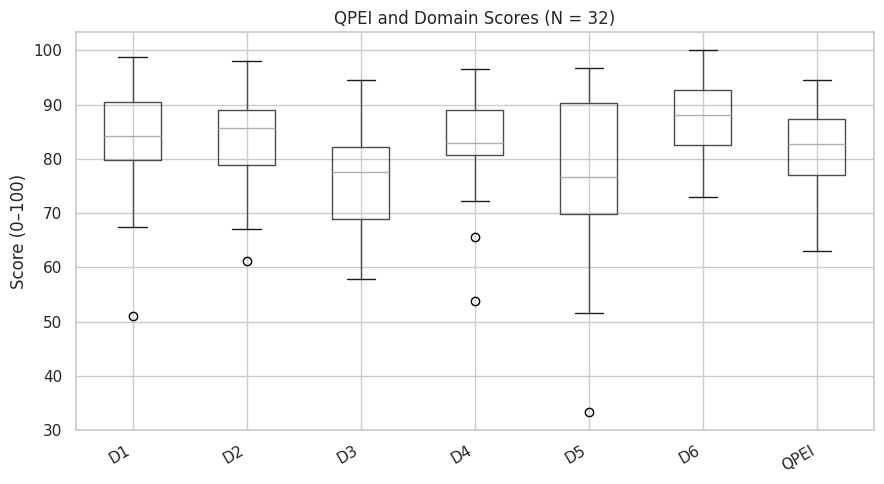

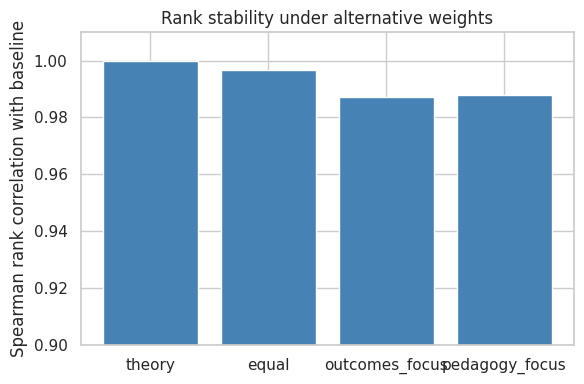

ROUND 5 COMPLETE
Schools scored : 32
Mean QPEI      : 81.9
Range          : 63.0 – 94.5
All outputs in : /content/drive/MyDrive/QPEI/qpei_round5_scoring

IMPORTANT: If any items were missing, edit the CROSSWALK cell and re-run from there.


In [11]:
# ============================================================
# 8. FIGURES + SUMMARY
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5))
final_public[list(WEIGHTS.keys()) + ["QPEI"]].boxplot(ax=ax)
ax.set_ylabel("Score (0–100)")
ax.set_title(f"QPEI and Domain Scores (N = {len(final_public)})")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "R5_Domain_Boxplot.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(sens_df["scheme"], sens_df["spearman_ranks"], color="steelblue")
ax.set_ylim(0.9, 1.01)
ax.set_ylabel("Spearman rank correlation with baseline")
ax.set_title("Rank stability under alternative weights")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "R5_Sensitivity_Ranks.png", dpi=150)
plt.show()

summary = {
    "n_schools_scored": int(len(final_public)),
    "mean_qpei": float(final_public["QPEI"].mean()),
    "sd_qpei": float(final_public["QPEI"].std()),
    "min_qpei": float(final_public["QPEI"].min()),
    "max_qpei": float(final_public["QPEI"].max()),
    "crosswalk_items": int(len(crosswalk_df)),
    "domain_counts": crosswalk_df.groupby("domain").size().to_dict(),
    "sensitivity": sens_df.to_dict(orient="records"),
    "leave_one_out": loo_df.to_dict(orient="records"),
    "generated": datetime.now().isoformat(timespec="seconds"),
}

with open(OUTPUT_DIR / "results_round5.json", "w") as f:
    json.dump(summary, f, indent=2)

print("=" * 90)
print("ROUND 5 COMPLETE")
print(f"Schools scored : {len(final_public)}")
print(f"Mean QPEI      : {final_public['QPEI'].mean():.1f}")
print(f"Range          : {final_public['QPEI'].min():.1f} – {final_public['QPEI'].max():.1f}")
print("All outputs in :", OUTPUT_DIR)
print("=" * 90)
print("\nIMPORTANT: If any items were missing, edit the CROSSWALK cell and re-run from there.")